# Regional aerosol cleanup vs a different emissions pathway: ssp585 as the anchor

The earlier East-Asia comparison (`pipeline/ks_gwl_1deg.ipynb`) tested `ssp370-EAS126aer` against
its own parent `ssp370`. That is almost a year-matched comparison — regional cleanup moves GMST by
~1 yr — so warming-level matching did little work. Here the anchor is **ssp585**: a different
emissions pathway (stronger GHG forcing, ssp5 aerosol trajectory) reaching GWL 2.0 up to 8 yr
earlier, so the pathways genuinely differ in composition and timing. Two comparisons, identical
pipeline (transform on native grid → xESMF 1° → block-permutation KS → Wilks FDR):

- `ssp585` vs `ssp370-EAS126aer` — East-Asia-only cleanup
- `ssp585` vs `ssp370-126aer` — global cleanup, for reference

Pairs are formed **within a `p<n>f<n>` variant** (the cross-experiment trap documented in
DATA.md §5): GISS pairs only inside p3f1, CanESM5 (ScenarioMIP) stands in for CanESM5-1 (RAMIP)
as it does elsewhere in the product. ssp585 has tas + pr only, so variables are tas, pr, gdp.

In [1]:
import os, re, warnings
os.environ.setdefault('ESMFMKFILE', '/burg-archive/home/mck2199/summer/.esmf/lib/esmf.mk')
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

RAMIP   = dir_list['raw'] + 'ramip/'
SCEN    = dir_list['raw'] + 'scenariomip/'
PRODUCT = dir_list['aux'] + 'gwl_timeseries.zarr'
KS_DIR  = dir_list['aux'] + 'diagnostics/regional_vs_ssp585/'
out_dir = dir_list['aux'] + '../figures/'
os.makedirs(KS_DIR, exist_ok=True)

GWL, ALPHA, FDR = 2.0, 0.05, 0.2
ANCHOR_EXP = 'ssp585'
OTHERS = {'eas': 'ssp370-EAS126aer', 'glob': 'ssp370-126aer'}
VARS = ['tas', 'pr', 'gdp']
# RAMIP MIROC6 is a different model state from CMIP6 MIROC6 (Arctic +5 K, Southern Ocean -1.2 K in
# the 86-yr ssp370 climatology, identical in r1 and r2; 360-day calendar) -> invalid across archives
EXCLUDE = ['MIROC6']
# ScenarioMIP model id -> RAMIP model id
MODEL_MAP = {'CanESM5': 'CanESM5-1', 'CESM2': 'CESM2', 'CNRM-ESM2-1': 'CNRM-ESM2-1',
             'GISS-E2-1-G': 'GISS-E2-1-G', 'MIROC6': 'MIROC6', 'MRI-ESM2-0': 'MRI-ESM2-0',
             'UKESM1-0-LL': 'UKESM1-0-LL'}

_gmst = xr.open_zarr(PRODUCT, group='gmst')
_gwl  = xr.open_zarr(PRODUCT, group='gwl')


def gwl_ends(mod, exp):
    ids = _gmst.run_id.sel(model=mod, exp=exp).values
    we  = _gwl.window_end.sel(model=mod, exp=exp, gwl=GWL).values
    return {str(r): int(e) for r, e in zip(ids, we) if r and np.isfinite(e)}


def variant(run):
    return re.search(r'(p\d+f\d+)$', run).group(1)


def variant_pairs(mod_a, exp_a, mod_b, exp_b):
    """(run_a, end_a, run_b, end_b) pairs formed within a p<n>f<n> variant, by sorted index"""
    a, b = gwl_ends(mod_a, exp_a), gwl_ends(mod_b, exp_b)
    by = lambda d: {v: sorted(r for r in d if variant(r) == v) for v in {variant(r) for r in d}}
    va, vb = by(a), by(b)
    out = []
    for v in sorted(set(va) & set(vb)):
        for ra, rb in zip(va[v], vb[v]):
            assert variant(ra) == variant(rb)
            out.append((ra, a[ra], rb, b[rb]))
    return out


PAIRS = {cmp: {ms: variant_pairs(ms, ANCHOR_EXP, mr, exp) for ms, mr in MODEL_MAP.items()}
         for cmp, exp in OTHERS.items()}
for cmp, exp in OTHERS.items():
    print(f'{ANCHOR_EXP} vs {exp}:')
    for ms, prs in PAIRS[cmp].items():
        if prs:
            lead = np.mean([ea - eb for _, ea, _, eb in prs])
            print(f'  {ms:12s} {len(prs):2d} pairs, variants {sorted({variant(p[0]) for p in prs})}, '
                  f'mean lead (anchor_end - other_end) {lead:+.1f} yr')

ssp585 vs ssp370-EAS126aer:
  CanESM5       5 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) -2.8 yr
  CESM2         3 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) -3.3 yr
  CNRM-ESM2-1   1 pairs, variants ['p1f2'], mean lead (anchor_end - other_end) +3.0 yr
  GISS-E2-1-G   5 pairs, variants ['p3f1'], mean lead (anchor_end - other_end) -1.0 yr
  MIROC6       10 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) -8.2 yr
  MRI-ESM2-0    6 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) -5.3 yr
  UKESM1-0-LL   5 pairs, variants ['p1f2'], mean lead (anchor_end - other_end) -1.2 yr
ssp585 vs ssp370-126aer:
  CanESM5       5 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) -2.2 yr
  CESM2         3 pairs, variants ['p1f1'], mean lead (anchor_end - other_end) +3.0 yr
  CNRM-ESM2-1   5 pairs, variants ['p1f2'], mean lead (anchor_end - other_end) +1.4 yr
  GISS-E2-1-G   5 pairs, variants ['p3f1'], mean lead (anchor_end - other_end

## KS on the common 1° grid

`kt.pair_ks_1deg` is the pipeline from `ks_gwl_1deg.ipynb`, now shared. Cache:
`diagnostics/regional_vs_ssp585/{cmp}_{var}_{model}.nc` (dims pair × lat × lon, 1°).

In [2]:
results = {}
for cmp, exp in OTHERS.items():
    for var in VARS:
        for ms, mr in MODEL_MAP.items():
            prs = PAIRS[cmp][ms]
            if not prs:
                continue
            cache_fn = f'{KS_DIR}{cmp}_{var}_{ms}.nc'
            if os.path.exists(cache_fn):
                results[(cmp, var, ms)] = xr.open_dataset(cache_fn).load()
                print(f'{cmp} {var} {ms}: loaded cache ({results[(cmp, var, ms)].sizes["pair"]} pairs)')
                continue
            src = kt.SRC_VAR.get(var, var)
            afns = kt.member_files(SCEN, ms, ANCHOR_EXP, src)
            bfns = kt.member_files(RAMIP, mr, exp, src)
            bp, asy, used = [], [], []
            for ra, ea, rb, eb in prs:
                if ra not in afns or rb not in bfns:
                    print(f'  {cmp} {var} {ms} {ra}/{rb}: no file, skipped'); continue
                out = kt.pair_ks_1deg(afns[ra], bfns[rb], var, ea, eb)
                if out is None:
                    print(f'  {cmp} {var} {ms} {ra}/{rb}: short window, skipped'); continue
                bp.append(out[0]); asy.append(out[1]); used.append(f'{ra}|{rb}')
                print(f'  {cmp} {var} {ms} {ra} vs {rb} done', flush=True)
            if not used:
                continue
            dims = ('pair', 'lat', 'lon')
            ds = xr.Dataset({'p_blockperm': (dims, np.stack(bp).astype('float32')),
                             'p_asymptotic': (dims, np.stack(asy).astype('float32'))},
                            coords={'pair': used, 'lat': kt.GRID_OUT['lat'], 'lon': kt.GRID_OUT['lon']})
            ds.attrs.update(gwl=GWL, variable=var, anchor=ANCHOR_EXP, other=exp,
                            anchor_model=ms, other_model=mr,
                            pairing='within p<n>f<n> variant, sorted index',
                            regrid=f"xESMF {kt.METHOD.get(var, 'bilinear')}, 1deg, transform-before-regrid")
            ds.to_netcdf(cache_fn)
            results[(cmp, var, ms)] = ds
            print(f'{cmp} {var} {ms}: {len(used)} pairs -> {cache_fn}')

eas tas CanESM5: loaded cache (5 pairs)
eas tas CESM2: loaded cache (3 pairs)
eas tas CNRM-ESM2-1: loaded cache (1 pairs)
eas tas GISS-E2-1-G: loaded cache (5 pairs)
eas tas MIROC6: loaded cache (10 pairs)
eas tas MRI-ESM2-0: loaded cache (6 pairs)
eas tas UKESM1-0-LL: loaded cache (5 pairs)
eas pr CanESM5: loaded cache (5 pairs)
eas pr CESM2: loaded cache (3 pairs)
eas pr CNRM-ESM2-1: loaded cache (1 pairs)
eas pr GISS-E2-1-G: loaded cache (5 pairs)
eas pr MIROC6: loaded cache (10 pairs)
eas pr MRI-ESM2-0: loaded cache (6 pairs)
eas pr UKESM1-0-LL: loaded cache (5 pairs)
eas gdp CanESM5: loaded cache (5 pairs)
eas gdp CESM2: loaded cache (3 pairs)
eas gdp CNRM-ESM2-1: loaded cache (1 pairs)
eas gdp GISS-E2-1-G: loaded cache (5 pairs)


eas gdp MIROC6: loaded cache (10 pairs)
eas gdp MRI-ESM2-0: loaded cache (6 pairs)
eas gdp UKESM1-0-LL: loaded cache (5 pairs)
glob tas CanESM5: loaded cache (5 pairs)
glob tas CESM2: loaded cache (3 pairs)
glob tas CNRM-ESM2-1: loaded cache (5 pairs)
glob tas GISS-E2-1-G: loaded cache (5 pairs)
glob tas MIROC6: loaded cache (10 pairs)
glob tas MRI-ESM2-0: loaded cache (6 pairs)
glob tas UKESM1-0-LL: loaded cache (5 pairs)
glob pr CanESM5: loaded cache (5 pairs)
glob pr CESM2: loaded cache (3 pairs)
glob pr CNRM-ESM2-1: loaded cache (5 pairs)
glob pr GISS-E2-1-G: loaded cache (5 pairs)
glob pr MIROC6: loaded cache (10 pairs)
glob pr MRI-ESM2-0: loaded cache (6 pairs)
glob pr UKESM1-0-LL: loaded cache (5 pairs)


glob gdp CanESM5: loaded cache (5 pairs)
glob gdp CESM2: loaded cache (3 pairs)
glob gdp CNRM-ESM2-1: loaded cache (5 pairs)
glob gdp GISS-E2-1-G: loaded cache (5 pairs)
glob gdp MIROC6: loaded cache (10 pairs)
glob gdp MRI-ESM2-0: loaded cache (6 pairs)
glob gdp UKESM1-0-LL: loaded cache (5 pairs)


## Land fractions: raw p<0.05 and Wilks FDR

Alongside the ssp370-anchored numbers from `ks_gwl_1deg.ipynb` for the same arms, so the
effect of changing the anchor pathway is read directly.

In [3]:
GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
prev = {'glob': (pd.read_csv(GWL_DIR + 'land_fractions_1deg.csv', index_col=0),
                 pd.read_csv(GWL_DIR + 'land_fractions_1deg_fdr.csv', index_col=0)),
        'eas':  (pd.read_csv(GWL_DIR + 'land_fractions_1deg_eas.csv', index_col=0),
                 pd.read_csv(GWL_DIR + 'land_fractions_1deg_fdr_eas.csv', index_col=0))}

tabs = {}
for cmp, exp in OTHERS.items():
    rows = []
    for ms, mr in MODEL_MAP.items():
        row = {'model': ms, 'n_pairs': len(PAIRS[cmp][ms])}
        for var in VARS:
            if (cmp, var, ms) in results:
                row[f'{var}_raw'] = kt.land_fraction(results[(cmp, var, ms)], 'pair', ALPHA)
                row[f'{var}_fdr'] = kt.fdr_land_fraction(results[(cmp, var, ms)], 'pair', FDR)
            if mr in prev[cmp][0].index and var in prev[cmp][0].columns:
                row[f'{var}_raw_vs370'] = prev[cmp][0].loc[mr, var]
                row[f'{var}_fdr_vs370'] = prev[cmp][1].loc[mr, var]
        rows.append(row)
    tabs[cmp] = pd.DataFrame(rows).set_index('model')
    tabs[cmp].to_csv(f'{KS_DIR}land_fractions_{cmp}.csv')
    print(f'\n{ANCHOR_EXP} vs {exp}  (…_vs370 = same arm against ssp370, from ks_gwl_1deg):')
    print(tabs[cmp].round(4).to_string())
    keep = tabs[cmp].drop(index=EXCLUDE, errors='ignore').drop(columns='n_pairs')
    print(f'means excluding {EXCLUDE} (cross-archive configuration mismatch):', keep.mean().round(4).to_dict())

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



ssp585 vs ssp370-EAS126aer  (…_vs370 = same arm against ssp370, from ks_gwl_1deg):
             n_pairs  tas_raw  tas_fdr  tas_raw_vs370  tas_fdr_vs370  pr_raw  pr_fdr  pr_raw_vs370  pr_fdr_vs370  gdp_raw  gdp_fdr  gdp_raw_vs370  gdp_fdr_vs370
model                                                                                                                                                           
CanESM5            5   0.0531   0.0000         0.0347         0.0000  0.0491  0.0000        0.0425        0.0000   0.0529   0.0000         0.0325         0.0000
CESM2              3   0.0435   0.0000         0.0468         0.0000  0.0429  0.0000        0.0535        0.0000   0.0408   0.0000         0.0466         0.0000
CNRM-ESM2-1        1   0.0551   0.0000         0.0395         0.0000  0.0452  0.0000        0.0454        0.0000   0.0511   0.0000         0.0366         0.0000
GISS-E2-1-G        5   0.0310   0.0000         0.0406         0.0000  0.0433  0.0000        0.0429        0.000


ssp585 vs ssp370-126aer  (…_vs370 = same arm against ssp370, from ks_gwl_1deg):
             n_pairs  tas_raw  tas_fdr  tas_raw_vs370  tas_fdr_vs370  pr_raw  pr_fdr  pr_raw_vs370  pr_fdr_vs370  gdp_raw  gdp_fdr  gdp_raw_vs370  gdp_fdr_vs370
model                                                                                                                                                           
CanESM5            5   0.0562   0.0000         0.0397         0.0000  0.0534  0.0000        0.0494           0.0   0.0595   0.0000         0.0412         0.0000
CESM2              3   0.0792   0.0000         0.0701         0.0000  0.0729  0.0000        0.0454           0.0   0.0676   0.0000         0.0617         0.0000
CNRM-ESM2-1        5   0.0601   0.0000         0.0477         0.0000  0.0507  0.0000        0.0446           0.0   0.0585   0.0000         0.0490         0.0000
GISS-E2-1-G        5   0.0364   0.0018         0.0449         0.0000  0.0445  0.0000        0.0472           0.0  

## Into the data product and figures

Group `ks_vs_ssp585` in `gwl_timeseries.zarr`, same layout as `ks`
(`p_blockperm(comparison, var, model, pair, lat, lon)`, `pair_id`).

wrote group ks_vs_ssp585: {'lat': 180, 'lon': 360, 'pair': 10, 'model': 7, 'var': 3, 'comparison': 2}
verify: round-trip exact for CanESM5


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_vs_ssp585_landfrac.png


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_regional_vs_ssp585_fracmaps.png


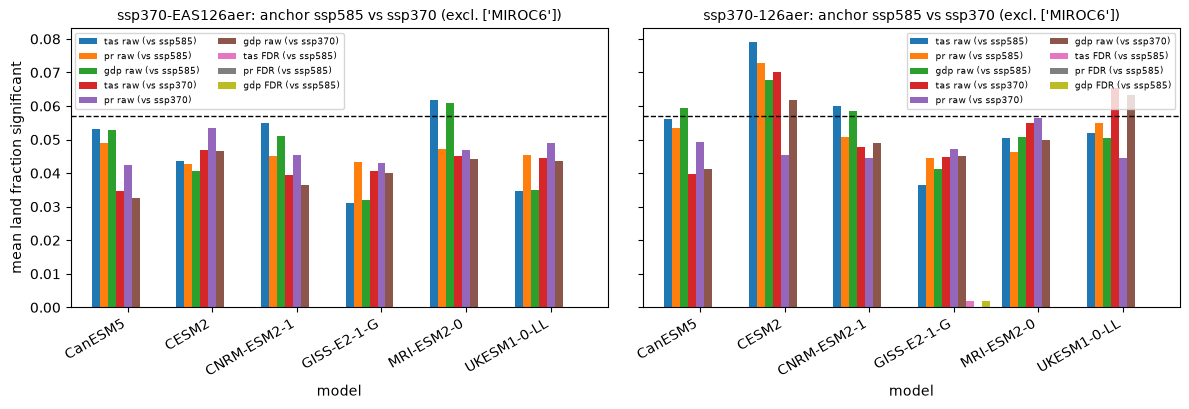

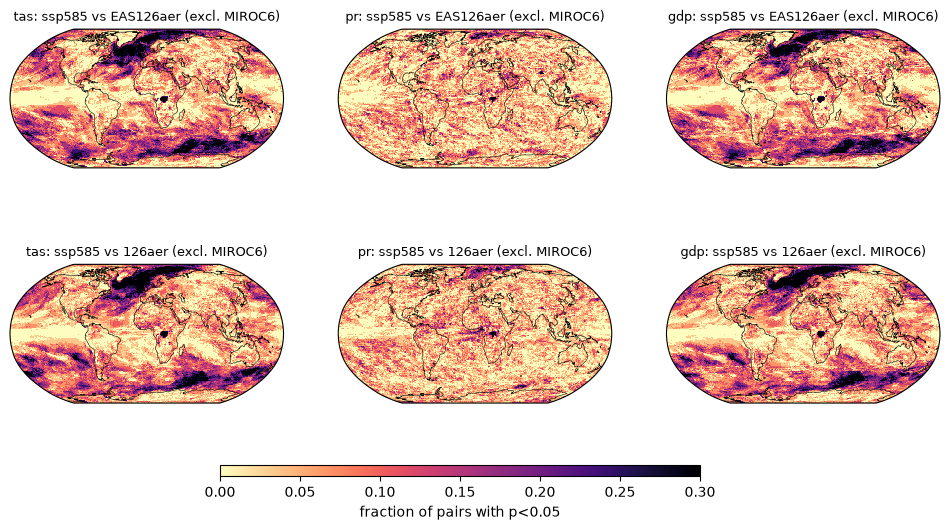

In [4]:
import shutil
per_cmp = []
for cmp, exp in OTHERS.items():
    per_var = []
    for var in VARS:
        per_mod = [results[(cmp, var, ms)].p_blockperm
                   .assign_coords(pair=np.arange(results[(cmp, var, ms)].sizes['pair']))
                   .assign_coords(model=ms)
                   for ms in MODEL_MAP if (cmp, var, ms) in results]
        per_var.append(xr.concat(per_mod, dim='model', join='outer').assign_coords(var=var))
    per_cmp.append(xr.concat(per_var, dim='var', join='outer')
                   .assign_coords(comparison=exp.replace('ssp370-', '')))
ks_da = xr.concat(per_cmp, dim='comparison', join='outer').astype('float32')
pid = xr.concat([xr.DataArray([str(p) for p in results[('eas', 'tas', ms)].pair.values], dims='pair')
                 .assign_coords(pair=np.arange(results[('eas', 'tas', ms)].sizes['pair']), model=ms)
                 for ms in MODEL_MAP if ('eas', 'tas', ms) in results],
                dim='model', join='outer').fillna('').astype('U40')
ks_ds = xr.Dataset({'p_blockperm': ks_da, 'pair_id': pid})
ks_ds.p_blockperm.attrs = {
    'long_name': f'block-permutation KS p, {ANCHOR_EXP} (ScenarioMIP) vs RAMIP cleanup arm at matched GWL 2.0',
    'comparison_note': 'EAS126aer = East-Asia-only cleanup, 126aer = global cleanup; anchor is ssp585',
    'pairing': 'within p<n>f<n> variant; pair_id = anchor_run|other_run; CanESM5 proxies CanESM5-1',
    'grid': '1deg regular, xESMF (bilinear; conservative for pr), transform-before-regrid',
    'gdp_definition': 'Burke-Hsiang-Miguel (2015) g(T) on monthly tas degC',
    'block_months': kt.BLOCK, 'ndraws': kt.NDRAWS, 'window_years': kt.WIN, 'alpha': ALPHA}
ks_ds.attrs = {'group': 'ks_vs_ssp585', 'created_by': 'path_independence/regional/ks_regional_vs_ssp585.ipynb', 'gwl': GWL}
shutil.rmtree(PRODUCT + '/ks_vs_ssp585', ignore_errors=True)
for v in list(ks_ds.variables):
    ks_ds[v].encoding = {}
ks_ds.chunk({'lat': kt.NLAT, 'lon': kt.NLON}).to_zarr(PRODUCT, group='ks_vs_ssp585', mode='a')
print('wrote group ks_vs_ssp585:', dict(ks_ds.sizes))
chk = xr.open_zarr(PRODUCT, group='ks_vs_ssp585')
m0 = next(ms for ms in MODEL_MAP if ('eas', 'gdp', ms) in results)
assert float(np.abs(results[('eas', 'gdp', m0)].p_blockperm.isel(pair=0).values
                    - chk.p_blockperm.sel(comparison='EAS126aer', var='gdp', model=m0).isel(pair=0).values).max()) == 0
print('verify: round-trip exact for', m0)

# --- figure 1: raw vs FDR land fractions, both anchors, both arms
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, cmp in zip(axs, OTHERS):
    t = tabs[cmp].drop(index=EXCLUDE, errors='ignore')
    d = pd.DataFrame({f'{v} raw (vs ssp585)': t[f'{v}_raw'] for v in VARS}
                     | {f'{v} raw (vs ssp370)': t.get(f'{v}_raw_vs370') for v in VARS if f'{v}_raw_vs370' in t}
                     | {f'{v} FDR (vs ssp585)': t[f'{v}_fdr'] for v in VARS})
    d.plot.bar(ax=ax, width=0.85)
    ax.axhline(0.057, color='k', ls='--', lw=1)
    ax.set_title(f'{OTHERS[cmp]}: anchor ssp585 vs ssp370 (excl. {EXCLUDE})', fontsize=10)
    ax.legend(fontsize=6.5, ncol=2)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
axs[0].set_ylabel('mean land fraction significant')
fig.tight_layout()
fig.savefig(out_dir + 'ks_regional_vs_ssp585_landfrac.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_regional_vs_ssp585_landfrac.png')

# --- figure 2: rejection-frequency maps, both comparisons
fig, axs = plt.subplots(2, len(VARS), figsize=(4 * len(VARS), 5.6),
                        subplot_kw={'projection': ccrs.Robinson()})
for row, (cmp, exp) in zip(axs, OTHERS.items()):
    tag = exp.replace('ssp370-', '')
    p = chk.p_blockperm.sel(comparison=tag).drop_sel(model=EXCLUDE, errors='ignore')
    rej = (p < ALPHA).where(p.notnull()).mean(('model', 'pair'))
    for ax, var in zip(row, VARS):
        fld = rej.sel(var=var)
        im = ax.pcolormesh(fld.lon, fld.lat, fld, cmap='magma_r', vmin=0, vmax=0.3, transform=ccrs.PlateCarree())
        ax.coastlines(lw=0.4); ax.set_title(f'{var}: ssp585 vs {tag} (excl. MIROC6)', fontsize=9)
cax = fig.add_axes([0.3, 0.03, 0.4, 0.02])
fig.colorbar(im, cax=cax, orientation='horizontal', label=f'fraction of pairs with p<{ALPHA}')
fig.savefig(out_dir + 'ks_regional_vs_ssp585_fracmaps.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_regional_vs_ssp585_fracmaps.png')